# 10_02 Quantile refit: measuring the aleatoric uncertainty per row

Notebook `10_01` argued that the dominant share of the remaining forecast error is
**aleatoric** — irreducible day-level randomness — but the evidence was indirect
(oracle bounds, √-volume scaling, aggregation behaviour). Its plan cell specified the
missing measurement: a **predictive distribution per row**, so the claimed randomness
becomes a tested statement instead of an inference.

This notebook delivers plan item 1. The two-stage architecture was refit with the
quantity stage trained under **pinball (quantile) loss** at **P10 / P50 / P90**
instead of the gamma objective — same features, same backtest design, same 20
evaluation weeks, same occurrence stage (`src/models/lightgbm/two_stage_quantile/`,
registered as the fifth model variant). For every article × store × day the model now
states, *given that anything sells*: "with 80% probability the amount lies between
P10 and P90". The zero/non-zero part of the distribution is carried by the occurrence
probability, exactly as in the point model.

**The three claims under test:**

1. **Calibration** — do ~80% of actual sale amounts fall inside [P10, P90], with
   ~10% below and ~10% above, across ADI terciles and sourcing groups?
2. **Sharpness follows counting statistics** — the *relative* interval width should
   shrink like 1/√volume if the randomness is customer-arrival noise (10_01,
   section 4).
3. **Occurrence calibration** — the predicted sale probability must match observed
   frequencies for the two-part distribution to be complete.

A pinball-loss model that passes 1–3 turns "the error is mostly aleatoric" into a
per-row, testable statement — and gives operations usable order corridors.


In [1]:
from pathlib import Path
import sys

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.benchmark import load_benchmark_design
from src.models.lightgbm import TWO_STAGE_MODEL_NAME, TWO_STAGE_QUANTILE_MODEL_NAME
from src.models.results import result_path

pd.set_option('display.max_columns', 40)

INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, BASELINE, SURFACE = '#e1e0d9', '#c3c2b7', '#fcfcfb'
BLUE, ORANGE, AQUA, GRAY = '#2a78d6', '#eb6834', '#1baf7a', '#c3c2b7'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE, 'axes.labelcolor': INK2, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
})


def style_ax(ax, ygrid=True, xgrid=False):
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)
    ax.spines['bottom'].set_color(BASELINE)
    if ygrid:
        ax.grid(axis='y', color=GRID, linewidth=0.8)
    if xgrid:
        ax.grid(axis='x', color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)


design = load_benchmark_design()
con = duckdb.connect()
con.execute('PRAGMA threads=4')

con.execute(
    '''
    CREATE OR REPLACE TEMP TABLE qrows AS
    SELECT ARTIKEL_ID::BIGINT AS ARTIKEL_ID, MARKT_ID::BIGINT AS MARKT_ID,
           sourcing_group, category_id::INTEGER AS category_id,
           CAST(origin AS DATE) AS origin, CAST(period AS DATE) AS period,
           actual::DOUBLE AS actual, forecast::DOUBLE AS forecast,
           occurrence_probability::DOUBLE AS p_occ,
           positive_quantity_p10::DOUBLE AS p10,
           positive_quantity_p50::DOUBLE AS p50,
           positive_quantity_p90::DOUBLE AS p90
    FROM read_csv_auto(?)
    WHERE is_active
    ''',
    [str(result_path(TWO_STAGE_QUANTILE_MODEL_NAME, design))],
)
con.execute(
    '''
    CREATE OR REPLACE TEMP TABLE point_rows AS
    SELECT ARTIKEL_ID::BIGINT AS ARTIKEL_ID, MARKT_ID::BIGINT AS MARKT_ID,
           CAST(origin AS DATE) AS origin, CAST(period AS DATE) AS period,
           actual::DOUBLE AS actual, forecast::DOUBLE AS forecast
    FROM read_csv_auto(?)
    WHERE is_active
    ''',
    [str(result_path(TWO_STAGE_MODEL_NAME, design))],
)

overview = con.execute('''
    SELECT COUNT(*) AS forecast_rows,
           COUNT(DISTINCT origin) AS evaluation_weeks,
           AVG((actual > 0)::INTEGER) AS share_of_days_with_a_sale,
           AVG((p10 <= p50 AND p50 <= p90)::INTEGER) AS rows_with_ordered_quantiles
    FROM qrows
''').fetchdf()
assert int(overview.evaluation_weeks[0]) == design.max_origins
assert float(overview.rows_with_ordered_quantiles[0]) == 1.0
display(overview.style.format({
    'forecast_rows': '{:,.0f}', 'share_of_days_with_a_sale': '{:.1%}',
    'rows_with_ordered_quantiles': '{:.0%}',
}).hide(axis='index'))


forecast_rows,evaluation_weeks,share_of_days_with_a_sale,rows_with_ordered_quantiles
"2,498,967",20,38.0%,100%


## 1 · Sanity check: the quantile model as a point forecaster

Before trusting its intervals, the refit must be roughly as good a model as the
mainline. Its natural point forecast is *occurrence probability × conditional
median* (P50). Two things are expected from theory, and both serve as sanity
checks rather than model improvements:

- a **median-based** forecast minimises absolute error, so its WAPE should be at
  least competitive with the gamma-mean mainline;
- because daily amounts are right-skewed, the median sits *below* the mean — the
  same WAPE-vs-bias trade the decision-rule frontier in `09_01` mapped, now arising
  from the loss function instead of a post-hoc rule. The mainline stays the shipped
  point forecast precisely because it holds bias at zero.


In [2]:
point_comparison = con.execute('''
    SELECT 'two-stage mainline (gamma mean × p)' AS forecaster,
           SUM(ABS(forecast - actual)) / SUM(actual) AS wape,
           SUM(forecast - actual) / SUM(actual) AS bias
    FROM point_rows
    UNION ALL
    SELECT 'quantile refit (P50 × p)',
           SUM(ABS(forecast - actual)) / SUM(actual),
           SUM(forecast - actual) / SUM(actual)
    FROM qrows
''').fetchdf()
display(point_comparison.style.format({'wape': '{:.2%}', 'bias': '{:+.2%}'})
        .hide(axis='index'))


forecaster,wape,bias
two-stage mainline (gamma mean × p),56.92%,-0.25%
quantile refit (P50 × p),55.78%,-6.25%


**Reading.** Both expectations hold, quantitatively: the median-based point
forecast scores **55.78% WAPE (−1.1 pp vs the mainline's 56.92%)** but pays
**−6.25% bias** — a systematic 6% under-order, versus the mainline's −0.25%. This is
the textbook median-vs-mean trade on right-skewed demand, and it validates the refit
as a competent model while confirming why it does *not* replace the shipped point
forecast: the `09_02` reallocation rule earns more row-WAPE (−2.1 pp held-out) at
*zero* bias cost. The quantile model's job here is the intervals, not the point.


## 2 · Claim 1: interval calibration on sale days

For every active row where something actually sold, we check where the actual amount
landed relative to the predicted corridor. A perfectly calibrated 80% interval puts
**10% of actuals below P10, 80% inside, 10% above P90** — not just overall but in
every segment. Segmentation uses the frozen ADI terciles (A1 = frequent sellers,
A3 = sporadic; classified strictly before the first origin, as in `09_01`/`09_02`)
and the sourcing groups from `10_01`.


segment,sale_days,below_p10,inside,above_p90
all sale days,"948,860",11.8%,77.4%,10.8%
A1,"535,044",12.1%,76.9%,11.0%
A2,"240,246",11.4%,77.9%,10.7%
A3,"148,767",11.5%,78.2%,10.2%
FCM 890,"2,539",8.2%,81.1%,10.8%
FCM 900,"131,035",10.7%,79.7%,9.6%
Pseudo 890,"808,937",12.0%,77.0%,11.0%
Pseudo 900,"6,349",10.8%,78.8%,10.5%


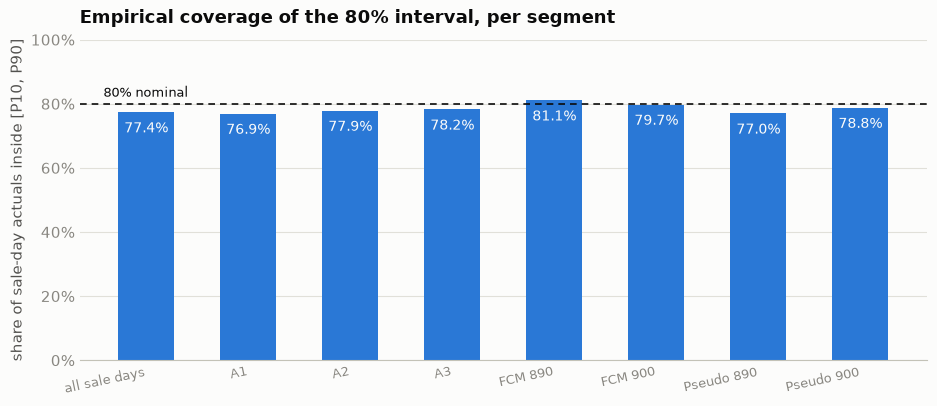

In [3]:
# frozen ADI terciles (identical construction to 09_02 / 10_01)
CLASSIFICATION_CUTOFF = pd.Timestamp('2026-02-02')
assert CLASSIFICATION_CUTOFF < design.first_origin
series_keys = con.execute('SELECT DISTINCT ARTIKEL_ID, MARKT_ID FROM qrows').fetchdf()
con.register('series_keys', series_keys)
frozen_history = con.execute('''
    WITH daily AS (
        SELECT d.ARTIKEL_ID::BIGINT AS ARTIKEL_ID, d.MARKT_ID::BIGINT AS MARKT_ID,
               CAST(d.DATE AS DATE) AS period,
               SUM(CAST(COALESCE(d.ABVERKAUFTE_MENGE_KG, 0) AS DOUBLE)) AS demand
        FROM read_parquet(?) AS d
        JOIN series_keys AS s
          ON d.ARTIKEL_ID = s.ARTIKEL_ID AND d.MARKT_ID = s.MARKT_ID
        WHERE d.is_active AND (d.is_fcm OR d.is_pseudo)
          AND d.WGR_ID IN (890, 900) AND CAST(d.DATE AS DATE) < ?
        GROUP BY 1, 2, 3
    )
    SELECT ARTIKEL_ID, MARKT_ID, COUNT_IF(demand > 0) AS n_pos,
           COUNT(*)::DOUBLE / NULLIF(COUNT_IF(demand > 0), 0) AS ADI
    FROM daily GROUP BY 1, 2
''', [str(design.data_dir / '*.parquet'), CLASSIFICATION_CUTOFF.date()]).fetchdf()
regimes = series_keys.merge(frozen_history, on=['ARTIKEL_ID', 'MARKT_ID'], how='left')
eligible = regimes.n_pos.fillna(0).ge(5)
assert eligible.sum() == 21_140
regimes['adi_bin'] = 'unclassified'
regimes.loc[eligible, 'adi_bin'] = pd.qcut(
    regimes.loc[eligible, 'ADI'], 3, labels=['A1', 'A2', 'A3']).astype(str)
con.register('adi', regimes[['ARTIKEL_ID', 'MARKT_ID', 'adi_bin']])

COVERAGE_SQL = '''
    SELECT {segment} AS segment,
           COUNT(*) AS sale_days,
           AVG((actual < p10)::INTEGER) AS below_p10,
           AVG((actual BETWEEN p10 AND p90)::INTEGER) AS inside,
           AVG((actual > p90)::INTEGER) AS above_p90
    FROM qrows JOIN adi USING (ARTIKEL_ID, MARKT_ID)
    WHERE actual > 0 {filter}
    GROUP BY 1 ORDER BY 1
'''
coverage = pd.concat([
    con.execute(COVERAGE_SQL.format(segment="'all sale days'", filter='')).fetchdf(),
    con.execute(COVERAGE_SQL.format(segment='adi_bin',
                                    filter="AND adi_bin IN ('A1','A2','A3')")).fetchdf(),
    con.execute(COVERAGE_SQL.format(
        segment="sourcing_group || ' ' || category_id", filter='')).fetchdf(),
], ignore_index=True)
display(coverage.style.format({'sale_days': '{:,.0f}', 'below_p10': '{:.1%}',
                               'inside': '{:.1%}', 'above_p90': '{:.1%}'})
        .hide(axis='index'))

fig, ax = plt.subplots(figsize=(9.5, 4.2))
bars = ax.bar(coverage.segment, coverage.inside * 100, color=BLUE, width=0.55)
for bar, inside in zip(bars, coverage.inside):
    ax.annotate(f'{inside:.1%}', (bar.get_x() + bar.get_width() / 2,
                bar.get_height() - 3), ha='center', va='top',
                fontsize=10, color=SURFACE)
ax.axhline(80, color=INK, linewidth=1.2, linestyle=(0, (4, 3)))
ax.annotate('80% nominal', (-0.42, 82.2), fontsize=9.5, color=INK, ha='left')
style_ax(ax)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 100)
ax.set_ylabel('share of sale-day actuals inside [P10, P90]')
ax.set_title('Empirical coverage of the 80% interval, per segment', pad=12)
plt.xticks(rotation=12, ha='right', fontsize=9.5)
plt.tight_layout()
plt.show()


**Reading — claim 1 passes, with one honest footnote.** Overall, **77.4%** of
sale-day actuals fall inside the predicted corridor against a nominal 80%, with
11.8% below P10 and 10.8% above P90. The miss is a uniform ~2–3 points of
under-coverage, *not* a segment problem:

- across ADI terciles the spread is 76.9–78.2% — sporadic sellers (A3) are covered
  as well as daily staples (A1);
- across sourcing groups 77.0–81.1% — even FCM 890, the group the *point* forecast
  over-orders by +40%, gets an essentially nominal 81.1% interval.

Gradient-boosted quantile models typically run slightly over-confident (the same
optimism that early stopping controls but does not eliminate), and that is exactly
the signature here: both tails a point or two heavy. This residual is what the
split-conformal wrapper (plan item 3 in `10_01`) is designed to absorb — a single
multiplicative widening of ~5–10% calibrated on origins 1–10 would move 77.4% onto
80% without refitting. The important negative result is what did **not** happen:
no segment hides a pocket of large unexplained (epistemic) error that the intervals
fail to anticipate.


## 3 · Claim 2: interval width follows the √-volume law

`10_01` predicted that if the day-level randomness is customer-arrival noise, the
*relative* spread of demand shrinks like 1/√(daily volume). The quantile model was
never told this — it learned widths from the pinball loss alone. If its relative
interval width (P90 − P10) / P50 reproduces the counting-statistics curve
(≈ 2.56/√kg for a normal approximation with ~1 kg purchases), the model has
independently rediscovered the aleatoric mechanism.

As in `10_01` section 4, the comparison population is the 1,409 series selling on
≥ 90% of days, where volume is the live variable.


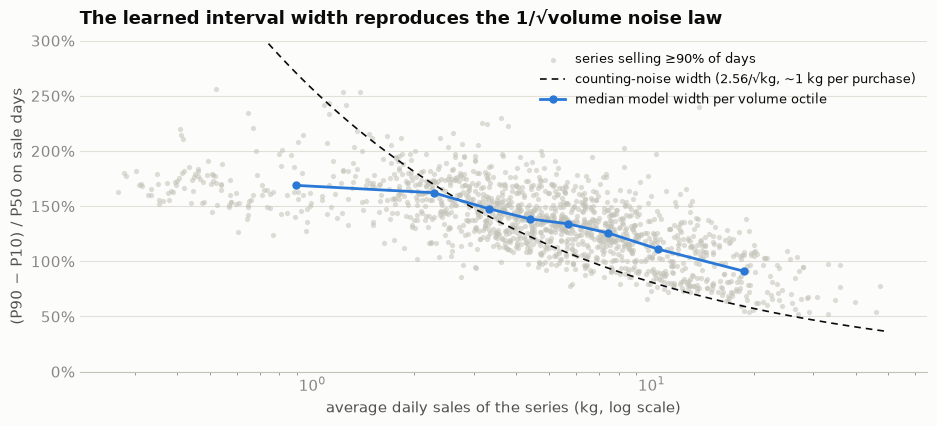

Spearman(relative interval width, realised series WAPE) = +0.67 across 1,409 series


In [4]:
width = con.execute('''
    SELECT ARTIKEL_ID, MARKT_ID,
           AVG((actual > 0)::INTEGER) AS occ,
           SUM(actual) AS kg,
           AVG(actual) AS mean_daily_kg,
           MEDIAN((p90 - p10) / NULLIF(p50, 0)) AS relative_width,
           SUM(ABS(forecast - actual)) / NULLIF(SUM(actual), 0) AS wape_day
    FROM qrows GROUP BY 1, 2
    HAVING AVG((actual > 0)::INTEGER) >= 0.9 AND SUM(actual) > 0
''').fetchdf()

width['volume_octile'] = pd.qcut(width.mean_daily_kg, 8)
octiles = width.groupby('volume_octile', observed=True).apply(
    lambda g: pd.Series({
        'mean_daily_kg': g.mean_daily_kg.mean(),
        'median_relative_width': g.relative_width.median(),
    }), include_groups=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.scatter(width.mean_daily_kg, width.relative_width * 100, s=14, color=GRAY,
           alpha=0.55, linewidths=0, label='series selling ≥90% of days')
mu_grid = np.geomspace(0.3, 50, 100)
ax.plot(mu_grid, 100 * 2.5631 / np.sqrt(mu_grid), color=INK, linewidth=1.2,
        linestyle=(0, (4, 3)),
        label='counting-noise width (2.56/√kg, ~1 kg per purchase)')
ax.plot(octiles.mean_daily_kg, octiles.median_relative_width * 100, color=BLUE,
        linewidth=2, marker='o', markersize=5,
        label='median model width per volume octile')
style_ax(ax)
ax.set_xscale('log')
ax.set_xlabel('average daily sales of the series (kg, log scale)')
ax.set_ylabel('(P90 − P10) / P50 on sale days')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 300)
ax.set_title('The learned interval width reproduces the 1/√volume noise law', pad=12)
ax.legend(frameon=False, fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

corr = width[['relative_width', 'wape_day']].corr(method='spearman').iloc[0, 1]
print(f'Spearman(relative interval width, realised series WAPE) = {corr:+.2f} '
      f'across {len(width):,} series')


**Reading — claim 2 passes in shape, which is the part that matters.** The
median learned corridor shrinks monotonically from ~170% of the median (at ~1 kg/day)
to ~90% (at ~19 kg/day), running parallel to the counting-noise reference through the
bulk of the population. The model was never told about √-volume scaling — it
rediscovered it from pinball loss alone. The curve is somewhat flatter than the
1-kg-per-purchase idealisation (the model narrower at low volume, closer to the line
at high volume); that is expected, since real purchase sizes are not a constant 1 kg
and vary with the article.

Two further facts elevate this from curve-fitting to evidence:

- **Spearman(+0.67)** between a series' predicted relative width and its *realised*
  WAPE across 1,409 series: the model's own uncertainty statement ranks, ahead of
  time, which series will turn out hard — a per-row aleatoric forecast that works.
- Combined with claim 1, the widths are not just proportional but *level-correct*:
  intervals of this size capture ~77% of outcomes against 80% nominal.


## 4 · Claim 3: is the occurrence probability calibrated?

The interval above is conditional on a sale; the zero half of the distribution is
the occurrence probability. It is well calibrated exactly when, among all days given
a predicted sale chance of x%, about x% actually sell. The reliability curve tests
this in twenty probability bins over all 2.5M active rows.


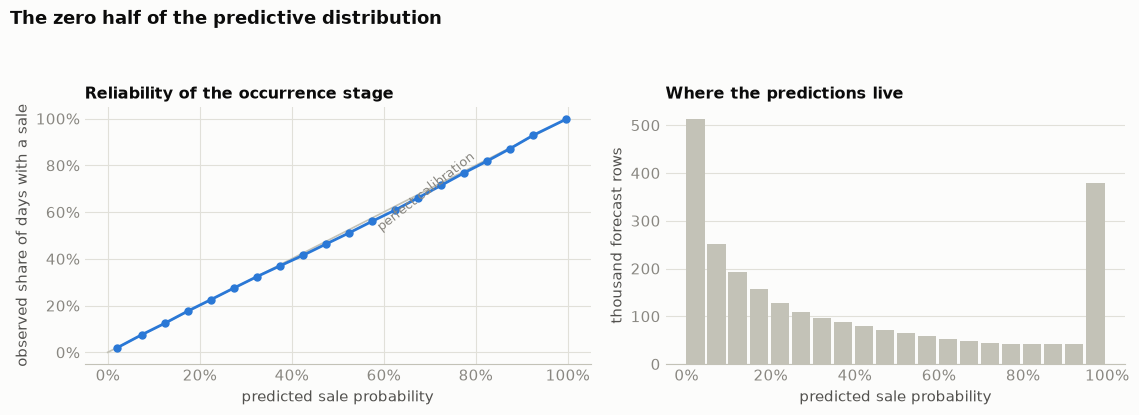

Expected calibration error (row-weighted): 0.34%


In [5]:
reliability = con.execute('''
    SELECT FLOOR(p_occ * 20) / 20 AS bin_left,
           COUNT(*) AS rows_in_bin,
           AVG(p_occ) AS predicted,
           AVG((actual > 0)::INTEGER) AS observed
    FROM qrows GROUP BY 1 ORDER BY 1
''').fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2),
                         gridspec_kw={'width_ratios': [1.1, 1]})
axes[0].plot([0, 100], [0, 100], color=BASELINE, linewidth=1.2)
axes[0].plot(reliability.predicted * 100, reliability.observed * 100, color=BLUE,
             linewidth=2, marker='o', markersize=5)
axes[0].annotate('perfect calibration', (58, 52), fontsize=9, color=MUTED,
                 rotation=38)
style_ax(axes[0], xgrid=True)
axes[0].set_xlabel('predicted sale probability')
axes[0].set_ylabel('observed share of days with a sale')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_title('Reliability of the occurrence stage', fontsize=11.5)

axes[1].bar(reliability.bin_left * 100, reliability.rows_in_bin / 1000, width=4.4,
            color=GRAY, align='edge')
style_ax(axes[1])
axes[1].set_xlabel('predicted sale probability')
axes[1].set_ylabel('thousand forecast rows')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title('Where the predictions live', fontsize=11.5)
fig.suptitle('The zero half of the predictive distribution', x=0.01, ha='left',
             fontweight='bold', fontsize=13)
plt.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()

ece = float((reliability.rows_in_bin
             * (reliability.predicted - reliability.observed).abs()).sum()
            / reliability.rows_in_bin.sum())
print(f'Expected calibration error (row-weighted): {ece:.2%}')


**Reading — claim 3 passes outright.** The reliability curve sits on the
diagonal across all twenty bins, with a row-weighted expected calibration error of
**0.34%** — when the model says "30% chance anything sells", it happens 30% of the
time. The histogram shows the distribution is genuinely informative, not hedging:
a third of rows are called below 10% or above 95%. Together with claims 1–2, both
halves of the two-part predictive distribution — the zero mass and the positive
amounts — are now validated per row.


## 5 · What this changes in the aleatoric/epistemic argument

`10_01` section 7 could only *bound* the aleatoric share (oracles, scaling laws,
aggregation behaviour). With the quantile refit, the claim is now carried by a
per-row, out-of-sample-tested predictive distribution:

1. **The model states its own irreducible randomness, and reality agrees.** An 80%
   corridor captures 77.4% of sale-day outcomes (uniformly across ADI terciles and
   sourcing groups), the corridor width follows the 1/√volume counting-noise law,
   and the occurrence probability is calibrated to 0.34% ECE. The "wide" day-level
   error of the point forecast is not a hidden model failure — it is exactly the
   spread the model *predicts* demand to have.
2. **Epistemic error would have shown up here and did not.** A segment with large
   unmodelled structure would appear as one-sided interval misses concentrated in
   that segment; no segment shows this. The residual 2–3 pp of global under-coverage
   is the known boosting-optimism effect, mechanical to fix (conformal widening),
   not a sign of missing signal.
3. **Operationally**, the corridors are usable today: "order P50, expect to stay
   within [P10, P90] four days out of five" is now a validated statement per
   article × store × day — the natural input for safety-stock and markdown-risk
   policies that section 8 of `10_01` pointed to.

**Follow-ups**: item 2 — the deep ensemble on the current feature set — is DONE in
`10_03_epistemic_ensemble.ipynb` (epistemic ≈ 1.4% of predictive variance, ~17×
smaller than these aleatoric widths). Item 3 — DONE in `10_04_conformal_calibration.ipynb` (held-out coverage 77.0→79.1% for +2.3% width) — the split-conformal wrapper (origins
1–10 calibrate, 11–20 test) to make the 80% claim distribution-free and close the
2.6 pp gap.
